# Import

In [13]:
import numpy as np
import torch
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torchvision import transforms
#import albumentations as albu

In [14]:
from torch.utils.data import Dataset
from typing import Union,List,Tuple
import pathlib
from PIL import Image
import matplotlib.pyplot as plt
from timeit import default_timer as timer
from torch.utils.data import DataLoader
import h5py
from tqdm import tqdm
import torchvision
import os
import datetime
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.ndimage import zoom
from sklearn.utils import shuffle
import time
from torch.utils.tensorboard import SummaryWriter

# Setup



In [15]:
class UNet_Light_RDN(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=True):
        super(UNet_Light_RDN, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(1, 32)
        self.down1 = Down(32, 64)
        self.down2 = Down(64, 128)
        self.down3 = Down(128, 256)
        self.down4 = Down(256, 256)
        self.up1 = Up(512, 128, bilinear)
        self.up2 = Up(256, 64, bilinear)
        self.up3 = Up(128, 32, bilinear)
        self.up4 = Up(64, 32, bilinear)
        self.outc = OutConv(32, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        else:
            self.up = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = torch.tensor([x2.size()[2] - x1.size()[2]])
        diffX = torch.tensor([x2.size()[3] - x1.size()[3]])
        x1 = nn.functional.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class AdjustMask(object):
    def __init__(self, class_num=3):
        self.class_num = class_num

    def __call__(self, sample):
        sample['mask'] = self.adjustMask(sample['mask'], self.class_num)
        return sample

    def adjustMask(self, mask, class_num):
        interval = int(256.0 / class_num)
        if len(mask.shape) == 2:
            new_mask = np.zeros((mask.shape[0], mask.shape[1]), dtype=np.longlong)
            for i in range(class_num):
                if i <= class_num - 2:
                    new_mask[(mask >= i * interval) & (mask < (i + 1) * interval)] = i
                else:
                    new_mask[i * interval <= mask] = i
            return new_mask

class Normalize(object):
    def __init__(self, max=255.0, min=0.0, tg_max=1.0, tg_min=0.0):
        self.max = max
        self.min = min
        self.tg_max = tg_max
        self.tg_min = tg_min

    def __call__(self, sample):
        image = sample['image'].astype('float32')
        image = self.tg_min + ((image - self.min) * (self.tg_max - self.tg_min)) / (self.max - self.min)
        sample['image'] = image
        return sample

class ToTensor(object):
    def __init__(self, if_multi_img=False):
        self.if_multi_img = if_multi_img

    def __call__(self, sample):
        image, mask = sample['image'], sample['mask']
        if not self.if_multi_img:
            if len(image.shape) == 2:
                image = np.expand_dims(image, axis=2)
            image = image.transpose((2, 0, 1))
        else:
            if len(image.shape) == 3:
                image = np.expand_dims(image, axis=3)
            image = image.transpose((0, 3, 1, 2))
        sample['image'] = torch.from_numpy(image)
        sample['mask'] = torch.from_numpy(mask)
        if 'weights' in sample:
            sample['weights'] = torch.from_numpy(sample['weights'])
        if 'ratio' in sample:
            sample['ratio'] = torch.from_numpy(sample['ratio'])
        return sample

class HDF52D(Dataset):
    def __init__(self, patches, transform=None):
        self.patches = patches
        self.transform = transform

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        patch = self.patches.iloc[idx]
        image = Image.open(patch['image_path']).convert('L')
        mask = Image.open(patch['mask_path']).convert('L')
        sample = {'image': np.array(image), 'mask': np.array(mask)}
        if self.transform:
            sample = self.transform(sample)
        return sample

# Loading the model

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model

model_path = "C:/Users/n.vanderesse/Desktop/STAGE_Nolan/Git/IA-SeReOs/RDN.pth"
net = UNet_Light_RDN(n_channels=1, n_classes=3)
net.load_state_dict(torch.load(model_path, map_location=device))
net.to(device)
net.eval()



UNet_Light_RDN(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (maxpool_conv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (double_conv): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(64, eps=1e-05, m

# Preprocessing Functions

In [17]:
def preprocess_image(image_path):
    image = Image.open(image_path).convert('L')  #convert to grayscale (just in case)
    transform = transforms.Compose([
        transforms.Resize((256, 256)),  # Resize to match training dimensions
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])
    return transform(image).unsqueeze(0)  # Add batch dimension

def preprocess_mask(mask_path):
    mask = Image.open(mask_path).convert('L')
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor()
    ])
    return transform(mask).unsqueeze(0)

# Inference

In [32]:
# Inference function with argmax 
def run_inference(image_path):
    input_tensor = preprocess_image(image_path).to(device)
    print(f"Input tensor shape: {input_tensor.shape}, dtype: {input_tensor.dtype}")  # Debugging line
    with torch.no_grad():
        output = net(input_tensor)
        print(f"Model output shape: {output.shape}, dtype: {output.dtype}")  # Debugging line
        pred = torch.argmax(output, dim=1).cpu().numpy()
    print(f"Prediction shape: {pred.shape}, unique values: {np.unique(pred)}")  # Debugging line    # cpu to use numpy and numpy for easier handling    # argmax to identify the class for each pixel in the image
    return pred[0]  # Remove batch dimension

In [19]:
# Inference function with softmax and automatic thresholds
def run_inference(image_path):
    input_tensor = preprocess_image(image_path).to(device)
    print(f"Input tensor shape: {input_tensor.shape}, dtype: {input_tensor.dtype}")  # Debugging line
    with torch.no_grad():
        output = net(input_tensor)
        print(f"Model output shape: {output.shape}, dtype: {output.dtype}")  # Debugging line
        
        # Apply softmax to get probabilities
        probabilities = torch.softmax(output, dim=1).cpu().numpy()
        print(f"Probabilities shape: {probabilities.shape}")  # Debugging line
        
        # Determine automatic thresholds based on minimum/mean probabilities
        thresholds = probabilities.mean(axis=(2, 3))[0]
        print(f"Automatic thresholds: {thresholds}")  # Debugging line
        
        # Initialize prediction array
        pred = np.zeros_like(probabilities[0][0], dtype=np.uint8)
        
        # Iterate through classes and apply individual thresholds
        for class_idx, threshold in enumerate(thresholds):
            class_map = probabilities[0][class_idx]
            pred[class_map > threshold] = class_idx
            
        # Debugging: Print the probability ranges for each class
        for class_idx in range(probabilities.shape[1]):
            print(f"Class {class_idx} probability range: {probabilities[0][class_idx].min()} to {probabilities[0][class_idx].max()}")
    
    print(f"Prediction shape: {pred.shape}, unique values: {np.unique(pred)}")  # Debugging line
    return pred

# Visualization

In [33]:
def visualize_results(image_path, prediction):
    image = Image.open(image_path).convert('L')
    

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(image, cmap='gray')   # display in grayscale 
    ax[0].set_title('Input Image')
    
    # Map each class to its corresponding grayscale intensity
    grayscale_map = {
        0: 255,  # Air (black)
        1: 128,  # Dirt (gray)
        2: 0     # Bone (white)
    }
    
    # Apply the grayscale map to the prediction
    segmented_image = np.zeros_like(prediction, dtype=np.uint8)
    for class_value, grayscale_value in grayscale_map.items():
        segmented_image[prediction == class_value] = grayscale_value

    ax[1].imshow(segmented_image, cmap='gray')
    ax[1].set_title('Predicted Mask')
    
    for a in ax:
        a.axis('off') # remove axis for more clarity
    plt.show()

# Application

Input tensor shape: torch.Size([1, 1, 256, 256]), dtype: torch.float32
Model output shape: torch.Size([1, 3, 256, 256]), dtype: torch.float32
Prediction shape: (1, 256, 256), unique values: [0 1]


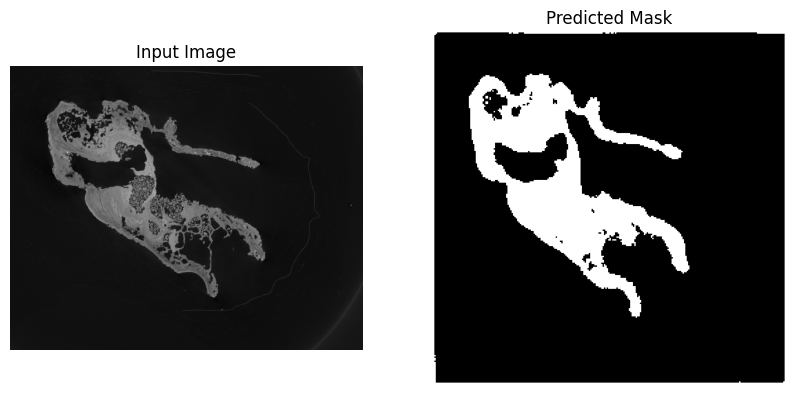

In [35]:
image_path = "D:/Donnees_pour_segmentation_RDN/data/Nicolas/dataset/unseg/EL_BARGA_Lot_2_Merged_Scans_1-32794.tif"

prediction = run_inference(image_path)#, threshold=0.05)
visualize_results(image_path, prediction)
